In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(42)

region1 = np.random.normal(loc=[25.0, 75.0, 1012, 40], scale=[1, 2, 5, 3], size=(30, 4))  # warm humid
region2 = np.random.normal(loc=[15.0, 45.0, 1008, 60], scale=[1, 2, 5, 3], size=(30, 4))  # cooler moderate
region3 = np.random.normal(loc=[5.0, 30.0, 1015, 80],  scale=[1, 2, 5, 3], size=(30, 4))  # cold moist

outliers = np.random.uniform(low=[-5, 10, 995, 20], high=[35, 85, 1030, 90], size=(5, 4))
data = np.vstack([region1, region2, region3, outliers])

columns = ["Temperature(°C)", "Humidity(%)", "Pressure(hPa)", "WindSpeed(km/h)"]
weather_df = pd.DataFrame(data, columns=columns)


In [3]:
print("\nBefore cleaning:")
print(weather_df.isnull().sum())

weather_df.fillna(weather_df.mean(), inplace=True)


Before cleaning:
Temperature(°C)    0
Humidity(%)        0
Pressure(hPa)      0
WindSpeed(km/h)    0
dtype: int64


In [4]:
features = weather_df[columns].values

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [6]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

weather_df["Cluster"] = labels

In [7]:
outliers_df = weather_df[weather_df["Cluster"] == -1]
print("\n📊 Number of clusters found (excluding noise):", len(set(labels)) - (1 if -1 in labels else 0))
print("📉 Number of outliers detected:", len(outliers_df))


📊 Number of clusters found (excluding noise): 3
📉 Number of outliers detected: 6


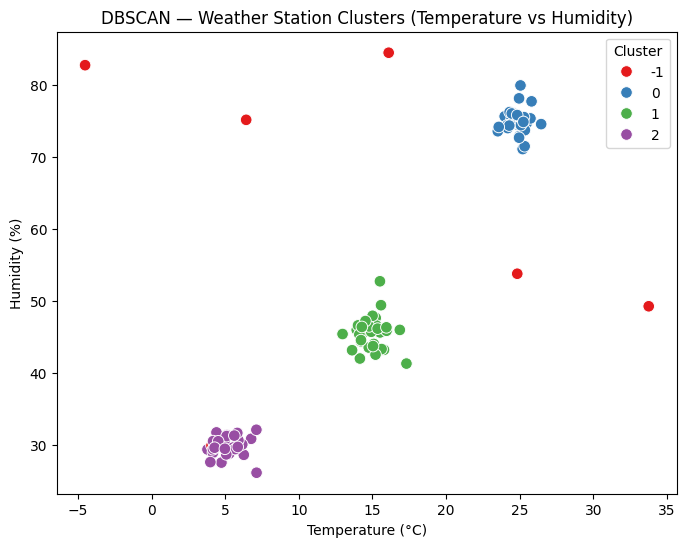

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=weather_df["Temperature(°C)"],
    y=weather_df["Humidity(%)"],
    hue=weather_df["Cluster"],
    palette="Set1",
    s=70
)
plt.title("DBSCAN — Weather Station Clusters (Temperature vs Humidity)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.legend(title="Cluster", loc="best")
plt.show()

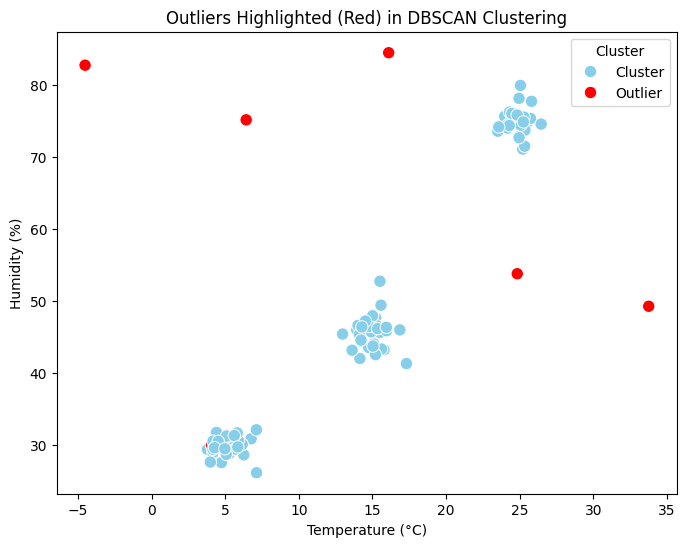

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=weather_df["Temperature(°C)"],
    y=weather_df["Humidity(%)"],
    hue=weather_df["Cluster"].apply(lambda x: 'Outlier' if x == -1 else 'Cluster'),
    palette={'Cluster': 'skyblue', 'Outlier': 'red'},
    s=80
)
plt.title("Outliers Highlighted (Red) in DBSCAN Clustering")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()

In [10]:
summary = weather_df.groupby("Cluster").mean()
print("\n📊 Cluster Summary (Mean Values per Cluster):")
print(summary.round(2))


📊 Cluster Summary (Mean Values per Cluster):
         Temperature(°C)  Humidity(%)  Pressure(hPa)  WindSpeed(km/h)
Cluster                                                              
-1                 13.45        62.54        1006.90            70.07
 0                 24.84        74.76        1011.56            40.16
 1                 14.97        45.46        1007.74            60.44
 2                  5.20        29.76        1016.18            79.74
